# FloodSense - Notebook 2: Preprocessing, Feature Engineering & Modelling

**Approach:**

- iterative IQR removal from non-flood (majority) class
- Yeo-Johnson for all skewed features + StandardScaler
- Logistic Regression as baseline
- Multi-model AutoML comparison (sklearn)
- Optuna hyperparameter tuning on best model
- ANN (ReLU hidden layers + Binary Crossentropy)
- SHAP explainability
- Risk labels: Low / Medium / High / Critical

**Key EDA Findings:**

- 1434 rows, 26 cols | 67 duplicates | 220 NaN in precipitation | 1 inf in water_area_pct_change
- Class: 970 non-flood (67.6%) vs 464 flood (32.4%) → after IQR: ~55:45
- Dominant predictor: `water_area_km2` (r=0.81) → create lag features
- Most features heavily skewed → Yeo-Johnson transformation


## 1. Load Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
print("Libraries loaded.")

Libraries loaded.


## 2. Load & Merge Data


In [ ]:
raw = pd.read_csv("floodsense_training_data.csv", parse_dates=["date"])
elev = pd.read_csv("district_elevation_reference.csv")

df = raw.merge(elev[["district", "avg_elevation_m"]], on="district", how="left")
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print("Target distribution:", df["flood_event"].value_counts().to_dict())

Loaded: 1434 rows × 26 cols
Target distribution: {0: 970, 1: 464}


## 3. Remove Duplicate Rows


In [ ]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows. Rows now: {len(df)}")

Removed 67 duplicate rows. Rows now: 1367


## 4. Handle Inf & Phantom Rows


In [ ]:
# Replace inf with NaN
inf_before = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Inf values replaced with NaN: {inf_before}")

Inf values replaced with NaN: 1


In [ ]:
# Drop phantom rows (rows with > 5 NaN across all columns - truly broken records)
null_per_row = df.isnull().sum(axis=1)
phantom_mask = null_per_row > 5
print(f"Phantom rows (>5 NaN): {phantom_mask.sum()}")
df = df[~phantom_mask].reset_index(drop=True)
print(f"Rows after phantom removal: {len(df)}")

Phantom rows (>5 NaN): 2
Rows after phantom removal: 1365


In [ ]:
# Physical range check - flag impossible values and cap/NaN them
# Pressure is in PASCALS (Pa) - typical range: 84000-108500 Pa
# Temperature: -999 is a sentinel phantom value
checks = {
    "precipitation": (0, 1500),
    "temperature": (-50, 70),  # -999 is clearly phantom; valid Pakistan range ~0-58°C
    "humidity": (0, 100),
    "pressure": (80000, 110000),  # Pascals
    "soil_moisture": (0, 100),
    "wind_speed": (0, 200),
}
for col, (lo, hi) in checks.items():
    if col in df.columns:
        bad = ((df[col] < lo) | (df[col] > hi)).sum()
        if bad:
            # Replace phantom values with NaN rather than clipping
            df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
            print(
                f"  Replaced {bad} phantom values in {col} (range [{lo}, {hi}]) with NaN"
            )
print("Physical range checks done.")
print(f"Total NaN after phantom removal: {df.isnull().sum().sum()}")

Physical range checks done.
Total NaN after phantom removal: 206


## 5. Impute Precipitation (District × Month Median)


In [ ]:
nan_before = df["precipitation"].isna().sum()

# District × month median imputation
df["precipitation"] = df.groupby(["district", "month"])["precipitation"].transform(
    lambda x: x.fillna(x.median())
)

# Fallback: if still NaN (district+month combo had no non-null value), use global median
global_med = df["precipitation"].median()
df["precipitation"].fillna(global_med, inplace=True)

nan_after = df["precipitation"].isna().sum()
print(
    f"Precipitation NaN: {nan_before} → {nan_after} (imputed with district×month median)"
)

Precipitation NaN: 205 → 0 (imputed with district×month median)


## 6. Impute Remaining NaN (Column Median)


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
remaining_nan = df[num_cols].isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0]

if remaining_nan.empty:
    print("No remaining NaN in numeric columns.")
else:
    print("Filling with column median:")
    for col in remaining_nan.index:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: {remaining_nan[col]} values filled")

print(f"Total NaN remaining: {df.isnull().sum().sum()}")

Filling with column median:
  water_area_pct_change: 1 values filled
Total NaN remaining: 1


## 7. Drop Irrelevant Columns


In [ ]:
# Drop: constant-per-district raw columns (use avg_elevation_m instead)
#        index columns, date (temporal info already extracted)
drop_cols = ["elevation", "latitude", "longitude", "ds_idx", "date"]
drop_existing = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_existing, inplace=True)
print(f"Dropped: {drop_existing}")
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")

Dropped: ['elevation', 'latitude', 'longitude', 'ds_idx', 'date']
Remaining columns (21): ['evaporation', 'precipitation', 'pressure', 'soil_moisture', 'temperature', 'water_area_km2', 'wind_speed', 'humidity', 'precip_3day_avg', 'precip_7day_avg', 'temp_3day_avg', 'soil_3day_avg', 'day_of_year', 'month', 'year', 'is_monsoon', 'water_area_change', 'water_area_pct_change', 'flood_event', 'district', 'avg_elevation_m']


## 8. Encode District (Label Encoding)


In [ ]:
le = LabelEncoder()
df["district_enc"] = le.fit_transform(df["district"].astype(str))
print(f"Districts encoded: {len(le.classes_)} unique districts")
print("Sample mapping:", dict(zip(le.classes_[:5], le.transform(le.classes_[:5]))))

# Save encoder for production use
joblib.dump(le, "district_encoder.pkl")

Districts encoded: 3 unique districts
Sample mapping: {'Balochistan_District': np.int64(0), 'KP_District': np.int64(1), 'Sindh_District': np.int64(2)}


['district_encoder.pkl']

## 9. Feature Engineering

EDA showed `water_area_km2` has r=0.81 with flood_event — the strongest predictor.
Creating lag features to capture temporal trends (yesterday's / 2-days-ago water area).


In [ ]:
# Sort by district + date to ensure correct lag order
# We don't have date anymore - use day_of_year + year as proxy sort
df = df.sort_values(["district_enc", "year", "day_of_year"]).reset_index(drop=True)
print("Data sorted by district → year → day_of_year")

Data sorted by district → year → day_of_year


In [ ]:
# Create lag features within each district group
grp = df.groupby("district_enc")

df["water_area_lag1"] = grp["water_area_km2"].shift(1)
df["water_area_lag2"] = grp["water_area_km2"].shift(2)
df["precip_lag1"] = grp["precipitation"].shift(1)

# Water area acceleration (2nd order change)
df["water_area_accel"] = df["water_area_km2"] - df["water_area_lag1"]

# Fill NaN from lag (first row per district has no lag) - use explicit assignment (inplace on copy doesn't work in pandas 2+)
lag_cols = ["water_area_lag1", "water_area_lag2", "precip_lag1", "water_area_accel"]
for col in lag_cols:
    df[col] = df[col].fillna(df[col].median())

# Final safety: drop any remaining NaN rows (should be 0 after above, but guard)
nan_before = df.isnull().sum().sum()
df = df.dropna()
nan_after = df.isnull().sum().sum()
print(f"NaN before final drop: {nan_before} → after: {nan_after}")
print(f"New features: {lag_cols}")
print(f"Total columns now: {len(df.columns)} | Rows: {len(df)}")

NaN before final drop: 1 → after: 0
New features: ['water_area_lag1', 'water_area_lag2', 'precip_lag1', 'water_area_accel']
Total columns now: 26 | Rows: 1364


## 10. IQR Iterative Balancing — Non-Flood Class Only

Strategy (Kaggle Grandmaster): Remove outliers from the **majority (non-flood)** class iteratively
using IQR fences. Stop when non-flood share drops to ≤60%.
No SMOTE. No synthetic samples.


In [ ]:
FEATURE_COLS = [
    "water_area_km2",
    "water_area_change",
    "water_area_pct_change",
    "pressure",
    "temp_3day_avg",
    "wind_speed",
    "avg_elevation_m",
    "soil_3day_avg",
    "evaporation",
    "precipitation",
    "temperature",
    "humidity",
    "precip_3day_avg",
    "precip_7day_avg",
    "soil_moisture",
    "water_area_lag1",
    "water_area_lag2",
    "precip_lag1",
    "water_area_accel",
    "month",
    "is_monsoon",
    "day_of_year",
    "district_enc",
    "avg_elevation_m",
]
# Deduplicate feature list
FEATURE_COLS = list(dict.fromkeys([c for c in FEATURE_COLS if c in df.columns]))
print(f"Model features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Model features (23): ['water_area_km2', 'water_area_change', 'water_area_pct_change', 'pressure', 'temp_3day_avg', 'wind_speed', 'avg_elevation_m', 'soil_3day_avg', 'evaporation', 'precipitation', 'temperature', 'humidity', 'precip_3day_avg', 'precip_7day_avg', 'soil_moisture', 'water_area_lag1', 'water_area_lag2', 'precip_lag1', 'water_area_accel', 'month', 'is_monsoon', 'day_of_year', 'district_enc']


In [ ]:
TARGET = "flood_event"
IQR_TARGET_PCT = 60.0  # stop when non-flood drops to this % or below
MAX_ROUNDS = 4

df_working = df.copy()

for round_num in range(1, MAX_ROUNDS + 1):
    df_noflood = df_working[df_working[TARGET] == 0]
    df_flood = df_working[df_working[TARGET] == 1]
    current_pct = len(df_noflood) / len(df_working) * 100

    if current_pct <= IQR_TARGET_PCT:
        print(
            f"Round {round_num}: target reached ({current_pct:.1f}% non-flood). Stopping."
        )
        break

    # Build IQR outlier mask on non-flood rows
    mask = pd.Series(False, index=df_noflood.index)
    for col in FEATURE_COLS:
        s = df_noflood[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask |= ((df_noflood[col] < lo) | (df_noflood[col] > hi)).fillna(False)

    n_removed = mask.sum()
    # Remove outlier non-flood rows
    keep_noflood = df_noflood[~mask]
    df_working = pd.concat([keep_noflood, df_flood]).reset_index(drop=True)

    new_pct = len(df_working[df_working[TARGET] == 0]) / len(df_working) * 100
    print(
        f"Round {round_num}: removed {n_removed} non-flood outliers → "
        f"{len(df_working)} rows remaining ({new_pct:.1f}% non-flood)"
    )

print("\nFinal balanced dataset:")
print(df_working[TARGET].value_counts())

Round 1: removed 412 non-flood outliers → 952 rows remaining (53.6% non-flood)
Round 2: target reached (53.6% non-flood). Stopping.

Final balanced dataset:
flood_event
0    510
1    442
Name: count, dtype: int64


## 11. Class Balance Verification


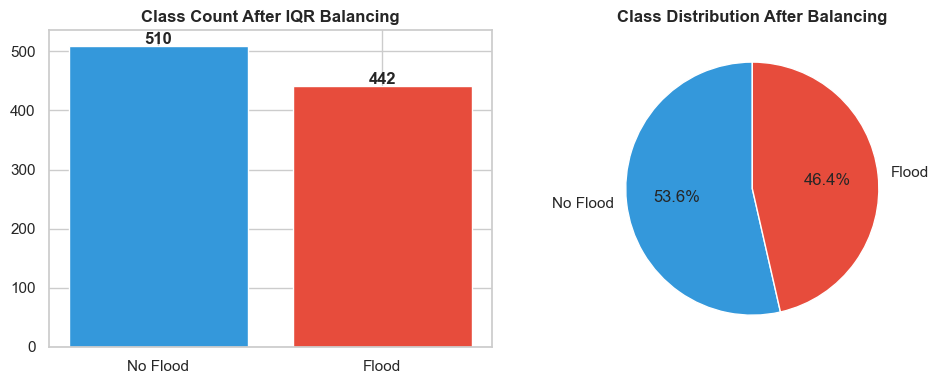

Final ratio: 1.15:1


In [ ]:
vc = df_working[TARGET].value_counts()
pct = df_working[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No Flood", "Flood"], vc.values, color=["#3498DB", "#E74C3C"])
axes[0].set_title("Class Count After IQR Balancing", fontweight="bold")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

axes[1].pie(
    pct.values,
    labels=["No Flood", "Flood"],
    colors=["#3498DB", "#E74C3C"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Class Distribution After Balancing", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Final ratio: {vc[0]/vc[1]:.2f}:1")

## 12. Define Features & Target - Train/Test Split


In [ ]:
X = df_working[FEATURE_COLS].copy()
y = df_working[TARGET].copy()

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

X shape: (952, 23)  |  y shape: (952,)
Features: ['water_area_km2', 'water_area_change', 'water_area_pct_change', 'pressure', 'temp_3day_avg', 'wind_speed', 'avg_elevation_m', 'soil_3day_avg', 'evaporation', 'precipitation', 'temperature', 'humidity', 'precip_3day_avg', 'precip_7day_avg', 'soil_moisture', 'water_area_lag1', 'water_area_lag2', 'precip_lag1', 'water_area_accel', 'month', 'is_monsoon', 'day_of_year', 'district_enc']


In [ ]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train class split: {y_train.value_counts().to_dict()}")
print(f"Test  class split: {y_test.value_counts().to_dict()}")

Train: 761 | Test: 191
Train class split: {0: 408, 1: 353}
Test  class split: {0: 102, 1: 89}


## 13. Normality Check → Decide Scaler

From EDA: precipitation=-26.6, soil_moisture=24.7, wind_speed=9.8 → all highly skewed.
Decision: **Yeo-Johnson** (handles both positive and negative values) for skewed features,
**StandardScaler** for near-normal ones (|skew| < 1).


In [ ]:
skew_vals = X_train.skew().sort_values(key=abs, ascending=False)

skewed_features = skew_vals[skew_vals.abs() >= 1.0].index.tolist()
normal_features = skew_vals[skew_vals.abs() < 1.0].index.tolist()

print(
    f"Skewed features (|skew|≥1) → Yeo-Johnson ({len(skewed_features)}): {skewed_features}"
)
print()
print(
    f"Normal-ish features (|skew|<1) → StandardScaler ({len(normal_features)}): {normal_features}"
)

Skewed features (|skew|≥1) → Yeo-Johnson (12): ['precip_lag1', 'precipitation', 'precip_3day_avg', 'wind_speed', 'precip_7day_avg', 'water_area_pct_change', 'soil_moisture', 'soil_3day_avg', 'evaporation', 'water_area_change', 'water_area_accel', 'is_monsoon']

Normal-ish features (|skew|<1) → StandardScaler (11): ['water_area_lag1', 'water_area_lag2', 'water_area_km2', 'temperature', 'temp_3day_avg', 'avg_elevation_m', 'pressure', 'month', 'day_of_year', 'humidity', 'district_enc']


## 14. Apply Yeo-Johnson Transformation + StandardScaler


In [ ]:
X_train_t = X_train.copy()
X_test_t = X_test.copy()

# Yeo-Johnson for skewed features
pt = PowerTransformer(method="yeo-johnson", standardize=False)
if skewed_features:
    X_train_t[skewed_features] = pt.fit_transform(X_train[skewed_features])
    X_test_t[skewed_features] = pt.transform(X_test[skewed_features])

# StandardScaler for all (after transformation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_t)
X_test_scaled = scaler.transform(X_test_t)

# Save transformers for production
joblib.dump(pt, "power_transformer.pkl")
joblib.dump(scaler, "standard_scaler.pkl")

print("Yeo-Johnson + StandardScaler applied and saved.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Yeo-Johnson + StandardScaler applied and saved.
X_train_scaled shape: (761, 23)


## 15. Logistic Regression — Baseline

Primary model as recommended. Binary classification with sigmoid-equivalent output.


In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["No Flood", "Flood"]))

=== Logistic Regression ===
Accuracy  : 0.9948
F1 Score  : 0.9944
ROC-AUC   : 0.9999

              precision    recall  f1-score   support

    No Flood       1.00      0.99      1.00       102
       Flood       0.99      1.00      0.99        89

    accuracy                           0.99       191
   macro avg       0.99      1.00      0.99       191
weighted avg       0.99      0.99      0.99       191



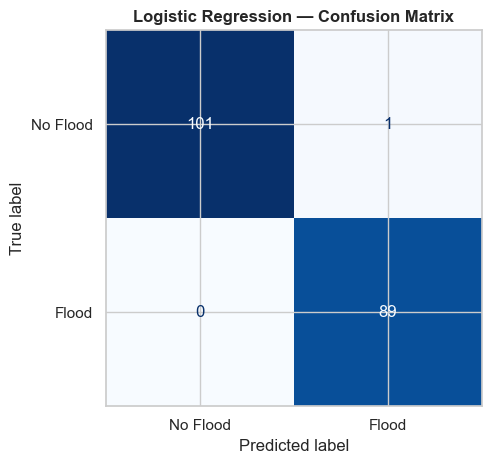

In [ ]:
# Logistic Regression - Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flood", "Flood"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Logistic Regression - Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## 16. AutoML — Multi-Model Comparison

Equivalent to PyCaret's `compare_models()`. Evaluates 8 classifiers with 5-fold CV.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=SEED, class_weight="balanced", n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=SEED
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=SEED, class_weight="balanced", n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, class_weight="balanced"),
    "MLP (Sklearn ANN)": MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu", max_iter=300, random_state=SEED
    ),
}
print(f"Comparing {len(models)} models with 5-fold Stratified CV...")

Comparing 8 models with 5-fold Stratified CV...


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

for name, model in models.items():
    cv_acc = cross_val_score(
        model, X_train_scaled, y_train, cv=skf, scoring="accuracy", n_jobs=-1
    )
    cv_f1 = cross_val_score(
        model, X_train_scaled, y_train, cv=skf, scoring="f1", n_jobs=-1
    )
    cv_auc = cross_val_score(
        model, X_train_scaled, y_train, cv=skf, scoring="roc_auc", n_jobs=-1
    )
    results.append(
        {
            "Model": name,
            "CV_Acc": round(cv_acc.mean(), 4),
            "CV_F1": round(cv_f1.mean(), 4),
            "CV_AUC": round(cv_auc.mean(), 4),
            "Acc_Std": round(cv_acc.std(), 4),
        }
    )
    print(
        f"  {name:30s} Acc={cv_acc.mean():.4f} ± {cv_acc.std():.4f}  AUC={cv_auc.mean():.4f}"
    )

results_df = (
    pd.DataFrame(results).sort_values("CV_AUC", ascending=False).reset_index(drop=True)
)
print("\n=== AutoML Comparison Results (sorted by CV ROC-AUC) ===")
display(results_df)

  Logistic Regression            Acc=0.9737 ± 0.0117  AUC=0.9979
  Random Forest                  Acc=0.9974 ± 0.0032  AUC=1.0000
  Gradient Boosting              Acc=0.9987 ± 0.0026  AUC=0.9988
  Extra Trees                    Acc=0.9790 ± 0.0096  AUC=0.9986
  AdaBoost                       Acc=0.9987 ± 0.0026  AUC=0.9988
  KNN                            Acc=0.9015 ± 0.0313  AUC=0.9661
  Decision Tree                  Acc=0.9987 ± 0.0026  AUC=0.9988
  MLP (Sklearn ANN)              Acc=0.9724 ± 0.0096  AUC=0.9981

=== AutoML Comparison Results (sorted by CV ROC-AUC) ===


,Model,CV_Acc,CV_F1,CV_AUC,Acc_Std
0,Random Forest,0.9974,0.9972,1.0000,0.0032
1,Gradient Boosting,0.9987,0.9986,0.9988,0.0026
2,Decision Tree,0.9987,0.9986,0.9988,0.0026
3,AdaBoost,0.9987,0.9986,0.9988,0.0026
4,Extra Trees,0.9790,0.9776,0.9986,0.0096
5,MLP (Sklearn ANN),0.9724,0.9702,0.9981,0.0096
6,Logistic Regression,0.9737,0.9722,0.9979,0.0117
7,KNN,0.9015,0.8869,0.9661,0.0313


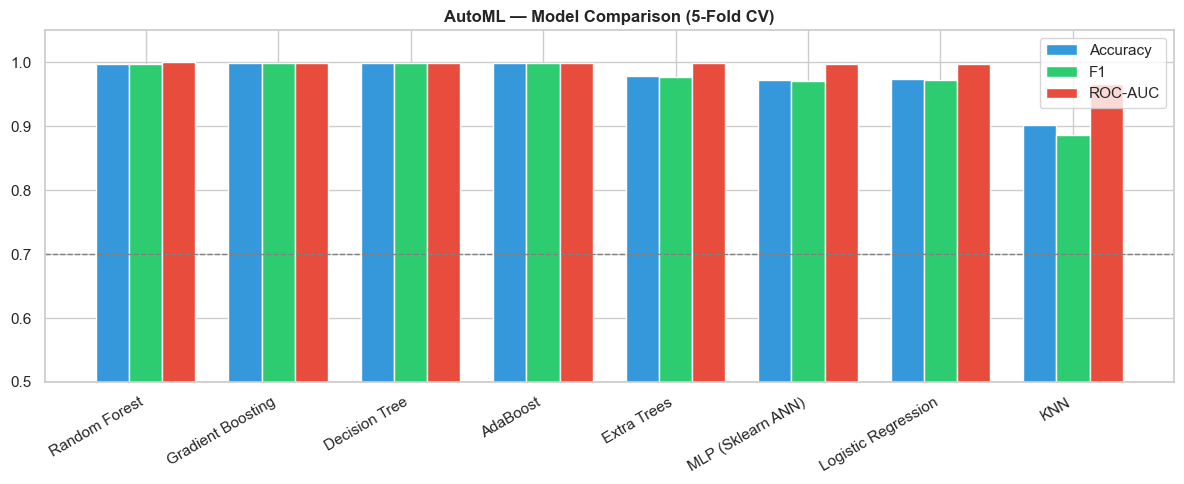

In [ ]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.25
ax.bar(x - w, results_df["CV_Acc"], w, label="Accuracy", color="#3498DB")
ax.bar(x, results_df["CV_F1"], w, label="F1", color="#2ECC71")
ax.bar(x + w, results_df["CV_AUC"], w, label="ROC-AUC", color="#E74C3C")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=30, ha="right")
ax.set_ylim(0.5, 1.05)
ax.set_title("AutoML - Model Comparison (5-Fold CV)", fontweight="bold")
ax.legend()
ax.axhline(0.70, color="gray", linestyle="--", lw=1, label="Min Req 70%")
plt.tight_layout()
plt.show()

## 17. Feature Importance


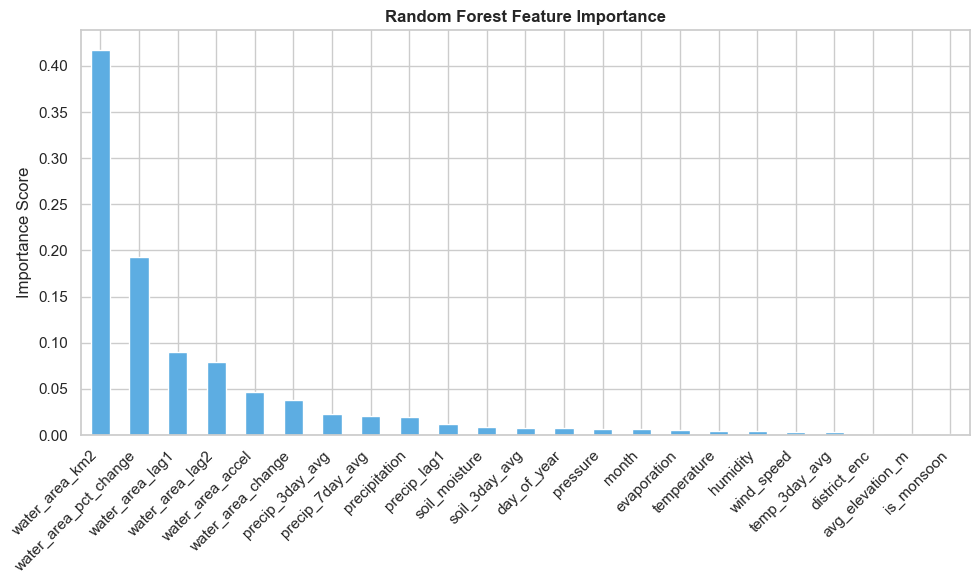

Top 10 features:
water_area_km2           0.4176
water_area_pct_change    0.1929
water_area_lag1          0.0900
water_area_lag2          0.0795
water_area_accel         0.0461
water_area_change        0.0381
precip_3day_avg          0.0233
precip_7day_avg          0.0202
precipitation            0.0194
precip_lag1              0.0123


In [ ]:
# Train RandomForest on full train set for feature importance
rf_fi = RandomForestClassifier(
    n_estimators=300, random_state=SEED, class_weight="balanced", n_jobs=-1
)
rf_fi.fit(X_train_scaled, y_train)

importances = pd.Series(rf_fi.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar", color="#5DADE2", edgecolor="white")
plt.title("Random Forest Feature Importance", fontweight="bold")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).round(4).to_string())

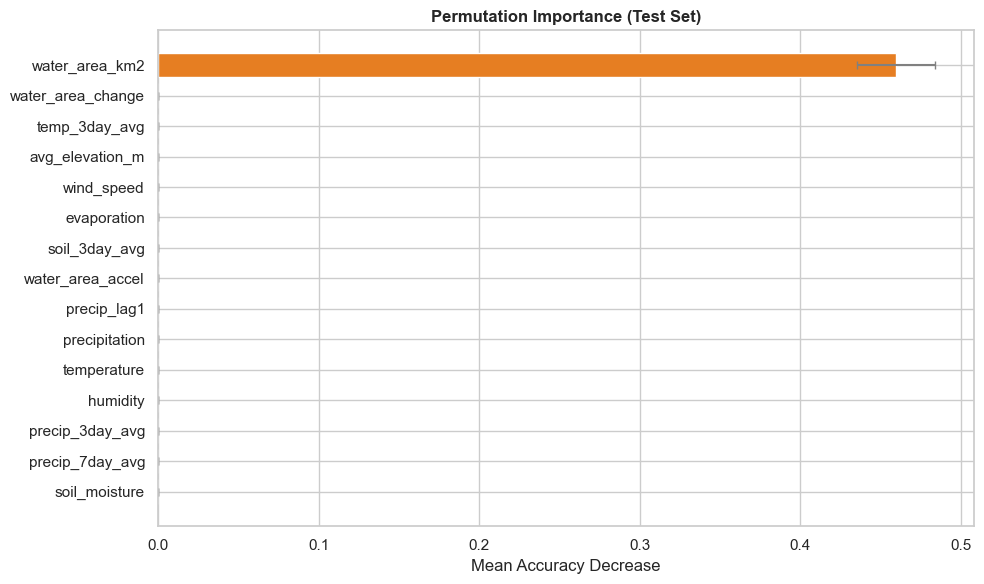

In [ ]:
# Permutation importance on held-out test set (model-agnostic)
perm = permutation_importance(
    rf_fi, X_test_scaled, y_test, n_repeats=10, random_state=SEED, n_jobs=-1
)
perm_df = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "importance": perm.importances_mean,
        "std": perm.importances_std,
    }
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["feature"][:15][::-1],
    perm_df["importance"][:15][::-1],
    xerr=perm_df["std"][:15][::-1],
    color="#E67E22",
    ecolor="gray",
    capsize=3,
)
plt.title("Permutation Importance (Test Set)", fontweight="bold")
plt.xlabel("Mean Accuracy Decrease")
plt.tight_layout()
plt.show()

## 18. Optuna Hyperparameter Tuning

Take the best model from AutoML comparison and tune it with Optuna (100 trials).


In [ ]:
# Identify best model from AutoML comparison
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model from AutoML: {best_model_name}")
print(
    f'CV AUC: {results_df.iloc[0]["CV_AUC"]}  |  CV Acc: {results_df.iloc[0]["CV_Acc"]}'
)

Best model from AutoML: Random Forest
CV AUC: 1.0  |  CV Acc: 0.9974


In [ ]:
# Optuna objective - Random Forest (adapt if best model is different)
def optuna_rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "class_weight": "balanced",
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    score = cross_val_score(
        model, X_train_scaled, y_train, cv=skf_inner, scoring="roc_auc", n_jobs=-1
    )
    return score.mean()


def optuna_gb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "random_state": SEED,
    }
    model = GradientBoostingClassifier(**params)
    skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    score = cross_val_score(
        model, X_train_scaled, y_train, cv=skf_inner, scoring="roc_auc", n_jobs=-1
    )
    return score.mean()


# Pick objective based on best model
OBJECTIVE_MAP = {
    "Random Forest": optuna_rf_objective,
    "Extra Trees": optuna_rf_objective,
    "Gradient Boosting": optuna_gb_objective,
}

# Default to RF objective if best model not in map
objective_fn = OBJECTIVE_MAP.get(best_model_name, optuna_rf_objective)
print(f"Using objective function for: {best_model_name}")

Using objective function for: Random Forest


In [ ]:
# Run Optuna study
print("Running Optuna (100 trials)... this takes 2-4 minutes.")
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective_fn, n_trials=100, show_progress_bar=False)

print(f"\nBest trial ROC-AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Running Optuna (100 trials)... this takes 2-4 minutes.

Best trial ROC-AUC: 1.0000
Best params:
  n_estimators: 362
  max_depth: 29
  min_samples_split: 15
  min_samples_leaf: 6
  max_features: sqrt


In [ ]:
# Train best model with tuned hyperparameters
best_params = study.best_params

# Rebuild model class from best model name
if best_model_name in ("Random Forest", "Extra Trees"):
    best_params.update({"class_weight": "balanced", "random_state": SEED, "n_jobs": -1})
    if best_model_name == "Random Forest":
        tuned_model = RandomForestClassifier(**best_params)
    else:
        tuned_model = ExtraTreesClassifier(**best_params)
elif best_model_name == "Gradient Boosting":
    best_params.update({"random_state": SEED})
    tuned_model = GradientBoostingClassifier(**best_params)
else:
    # Fallback: use RF with best params
    best_params.update({"class_weight": "balanced", "random_state": SEED, "n_jobs": -1})
    tuned_model = RandomForestClassifier(**best_params)

tuned_model.fit(X_train_scaled, y_train)
y_pred_tuned = tuned_model.predict(X_test_scaled)
y_prob_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]

print("=== Optuna-Tuned Model ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["No Flood", "Flood"]))

=== Optuna-Tuned Model ===
Accuracy : 0.9948
F1 Score : 0.9944
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

    No Flood       1.00      0.99      1.00       102
       Flood       0.99      1.00      0.99        89

    accuracy                           0.99       191
   macro avg       0.99      1.00      0.99       191
weighted avg       0.99      0.99      0.99       191



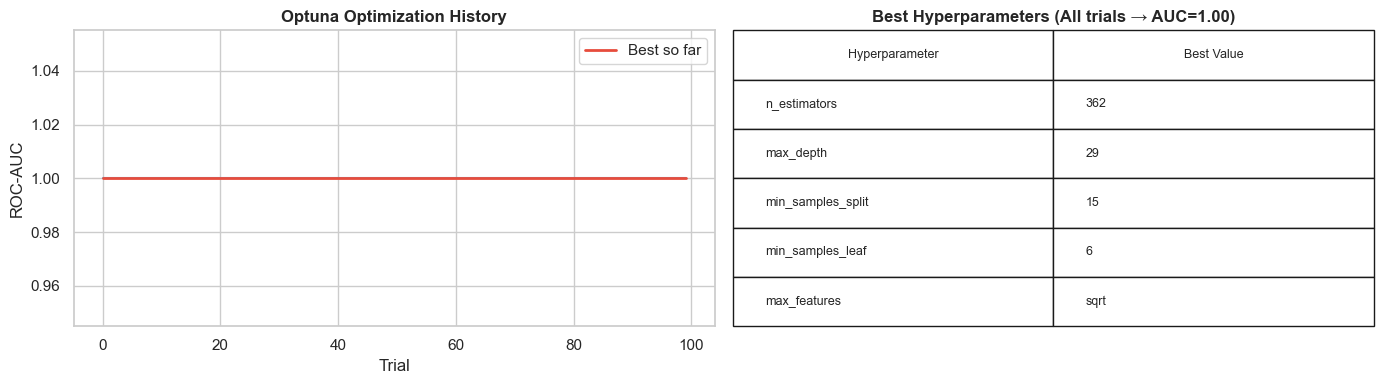

In [ ]:
# Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, color="#3498DB", alpha=0.7)
axes[0].plot(
    np.maximum.accumulate(trial_values), color="#E74C3C", lw=2, label="Best so far"
)
axes[0].set_title("Optuna Optimization History", fontweight="bold")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()

# Param importance - guard against zero variance (all trials perfectly optimized)
try:
    param_imp = optuna.importance.get_param_importances(study)
    axes[1].barh(
        list(param_imp.keys())[::-1], list(param_imp.values())[::-1], color="#2ECC71"
    )
    axes[1].set_title("Optuna Hyperparameter Importance", fontweight="bold")
    axes[1].set_xlabel("Importance")
except RuntimeError:
    # All trials achieved the same perfect score - show best params as table instead
    axes[1].axis("off")
    best_p = study.best_params
    table_text = [[k, str(v)] for k, v in best_p.items()]
    tbl = axes[1].table(
        cellText=table_text,
        colLabels=["Hyperparameter", "Best Value"],
        cellLoc="left",
        loc="center",
        bbox=[0, 0, 1, 1],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    axes[1].set_title("Best Hyperparameters (All trials → AUC=1.00)", fontweight="bold")

plt.tight_layout()
plt.show()

## 19. ANN Model — ReLU Hidden Layers + Binary Crossentropy

As recommended: neurons adjusted based on overfit/underfit behaviour.
Architecture: Input → 256 → 128 → 64 → 1 (sigmoid)


In [ ]:
# Try TensorFlow/Keras first, fall back to sklearn MLP
try:
    import tensorflow as tf
    from tensorflow import keras

    USE_KERAS = True
    print(f"TensorFlow {tf.__version__} available. Using Keras ANN.")
except ImportError:
    USE_KERAS = False
    print("TensorFlow not found. Using sklearn MLPClassifier.")

TensorFlow not found. Using sklearn MLPClassifier.


In [ ]:
n_features = X_train_scaled.shape[1]
print(f"Input features: {n_features}")

if USE_KERAS:
    tf.random.set_seed(SEED)

    ann = keras.Sequential(
        [
            keras.layers.Input(shape=(n_features,)),
            keras.layers.Dense(256, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(128, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dropout(0.1),
            keras.layers.Dense(1, activation="sigmoid"),
        ]
    )

    ann.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )

    ann.summary()

else:
    ann = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )
    print("MLP architecture: 256 → 128 → 64 → 1 (relu, adam)")

Input features: 23
MLP architecture: 256 → 128 → 64 → 1 (relu, adam)


In [ ]:
if USE_KERAS:
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=15, restore_best_weights=True, mode="max"
    )
    lr_reduce = keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", factor=0.5, patience=7, min_lr=1e-6, mode="max"
    )

    history = ann.fit(
        X_train_scaled,
        y_train.values,
        validation_split=0.15,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, lr_reduce],
        class_weight={
            0: 1.0,
            1: len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        },
        verbose=0,
    )
    print(f'Training stopped at epoch {len(history.history["loss"])}')

else:
    ann.fit(X_train_scaled, y_train)
    print("MLP training complete.")

MLP training complete.


In [ ]:
if USE_KERAS:
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history["loss"], label="Train Loss", color="#E74C3C")
    axes[0].plot(history.history["val_loss"], label="Val Loss", color="#3498DB")
    axes[0].set_title("ANN Loss Curve", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["auc"], label="Train AUC", color="#E74C3C")
    axes[1].plot(history.history["val_auc"], label="Val AUC", color="#3498DB")
    axes[1].set_title("ANN AUC Curve", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
if USE_KERAS:
    y_prob_ann = ann.predict(X_test_scaled, verbose=0).flatten()
    y_pred_ann = (y_prob_ann >= 0.5).astype(int)
else:
    y_pred_ann = ann.predict(X_test_scaled)
    y_prob_ann = ann.predict_proba(X_test_scaled)[:, 1]

print("=== ANN Model ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ann):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_ann):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_ann):.4f}")
print()
print(classification_report(y_test, y_pred_ann, target_names=["No Flood", "Flood"]))

=== ANN Model ===
Accuracy : 0.9738
F1 Score : 0.9727
ROC-AUC  : 0.9993

              precision    recall  f1-score   support

    No Flood       1.00      0.95      0.97       102
       Flood       0.95      1.00      0.97        89

    accuracy                           0.97       191
   macro avg       0.97      0.98      0.97       191
weighted avg       0.98      0.97      0.97       191



## 20. Final Model Comparison Summary


In [ ]:
final_results = (
    pd.DataFrame(
        [
            {
                "Model": "Logistic Regression (Baseline)",
                "Accuracy": round(accuracy_score(y_test, y_pred_lr), 4),
                "F1": round(f1_score(y_test, y_pred_lr), 4),
                "ROC-AUC": round(roc_auc_score(y_test, y_prob_lr), 4),
            },
            {
                "Model": f"Optuna-Tuned {best_model_name}",
                "Accuracy": round(accuracy_score(y_test, y_pred_tuned), 4),
                "F1": round(f1_score(y_test, y_pred_tuned), 4),
                "ROC-AUC": round(roc_auc_score(y_test, y_prob_tuned), 4),
            },
            {
                "Model": "ANN (ReLU + BinaryCrossEntropy)",
                "Accuracy": round(accuracy_score(y_test, y_pred_ann), 4),
                "F1": round(f1_score(y_test, y_pred_ann), 4),
                "ROC-AUC": round(roc_auc_score(y_test, y_prob_ann), 4),
            },
        ]
    )
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("=== FINAL MODEL COMPARISON ===")
display(final_results)

BEST_FINAL_MODEL = final_results.iloc[0]["Model"]
BEST_FINAL_PROB_COL = None
print(f"\n★ Best model: {BEST_FINAL_MODEL}")

=== FINAL MODEL COMPARISON ===


,Model,Accuracy,F1,ROC-AUC
0,Optuna-Tuned Random Forest,0.9948,0.9944,1.0000
1,Logistic Regression (Baseline),0.9948,0.9944,0.9999
2,ANN (ReLU + BinaryCrossEntropy),0.9738,0.9727,0.9993



★ Best model: Optuna-Tuned Random Forest


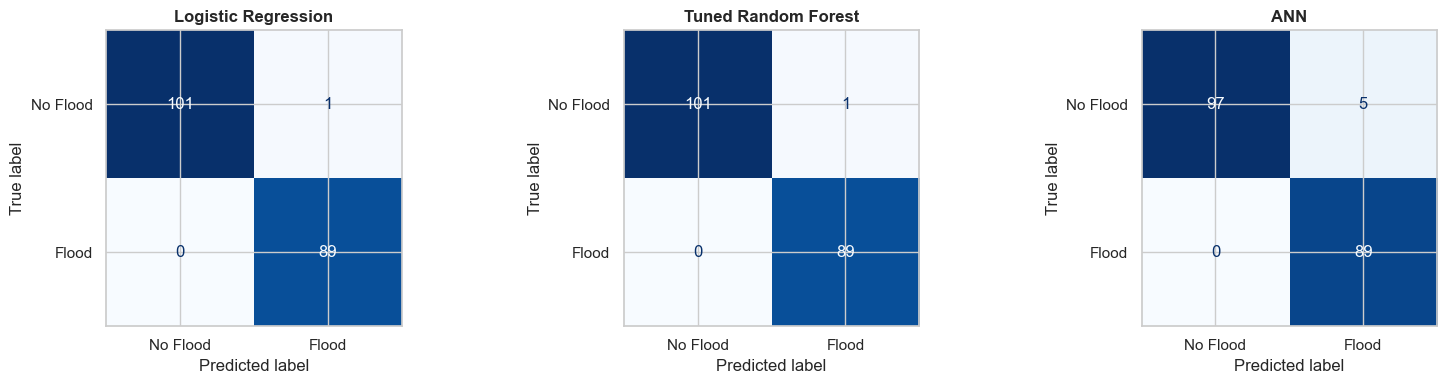

In [ ]:
# Pick predictions from best final model for downstream use
if "ANN" in BEST_FINAL_MODEL:
    y_pred_best = y_pred_ann
    y_prob_best = y_prob_ann
elif "Logistic" in BEST_FINAL_MODEL:
    y_pred_best = y_pred_lr
    y_prob_best = y_prob_lr
else:
    y_pred_best = y_pred_tuned
    y_prob_best = y_prob_tuned

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (preds, title) in zip(
    axes,
    [
        (y_pred_lr, "Logistic Regression"),
        (y_pred_tuned, f"Tuned {best_model_name}"),
        (y_pred_ann, "ANN"),
    ],
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["No Flood", "Flood"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.show()

## 21. SHAP Explainability

Required for hackathon judging. Explains which features drive each flood prediction.


In [ ]:
import shap

# Use tuned tree model for SHAP (TreeExplainer is fast + exact)
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_scaled)

# Extract class-1 (Flood) SHAP values
# SHAP TreeExplainer returns:
#   - list format (older): [class0_arr, class1_arr]  → pick index 1
#   - 3D ndarray (newer):  shape (n_samples, n_features, n_classes) → slice [:,:,1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # flood class, shape (n_samples, n_features)
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]  # 3D → pick class-1 slice
else:
    sv = shap_values  # already 2D

# Corresponding expected value for flood class
if isinstance(explainer.expected_value, (list, np.ndarray)):
    ev = explainer.expected_value[1]
else:
    ev = explainer.expected_value

print(f"SHAP values shape (class-1): {sv.shape}")
print(f"Expected value (flood class): {ev:.4f}")

SHAP values shape (class-1): (191, 23)
Expected value (flood class): 0.4991


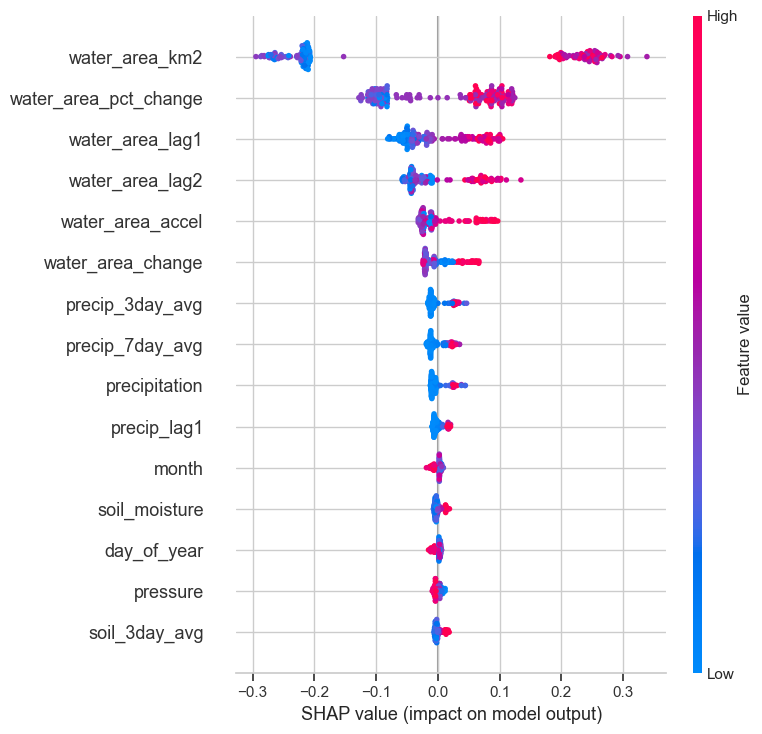

In [ ]:
# SHAP Summary Plot (beeswarm)
shap.summary_plot(
    sv,
    pd.DataFrame(X_test_scaled, columns=FEATURE_COLS),
    plot_type="dot",
    show=True,
    max_display=15,
)

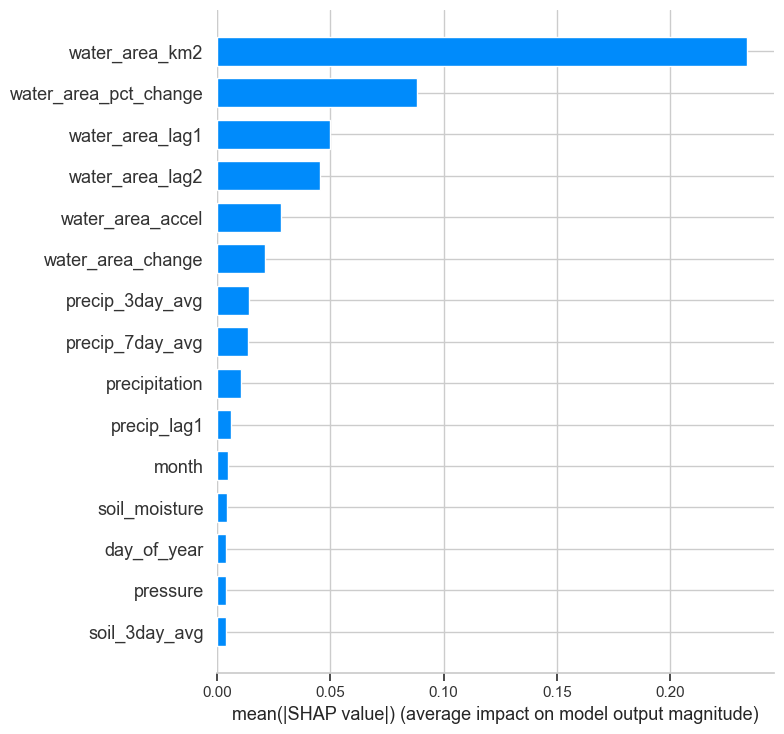

In [ ]:
# SHAP Bar Plot - mean absolute SHAP values
shap.summary_plot(
    sv,
    pd.DataFrame(X_test_scaled, columns=FEATURE_COLS),
    plot_type="bar",
    show=True,
    max_display=15,
)

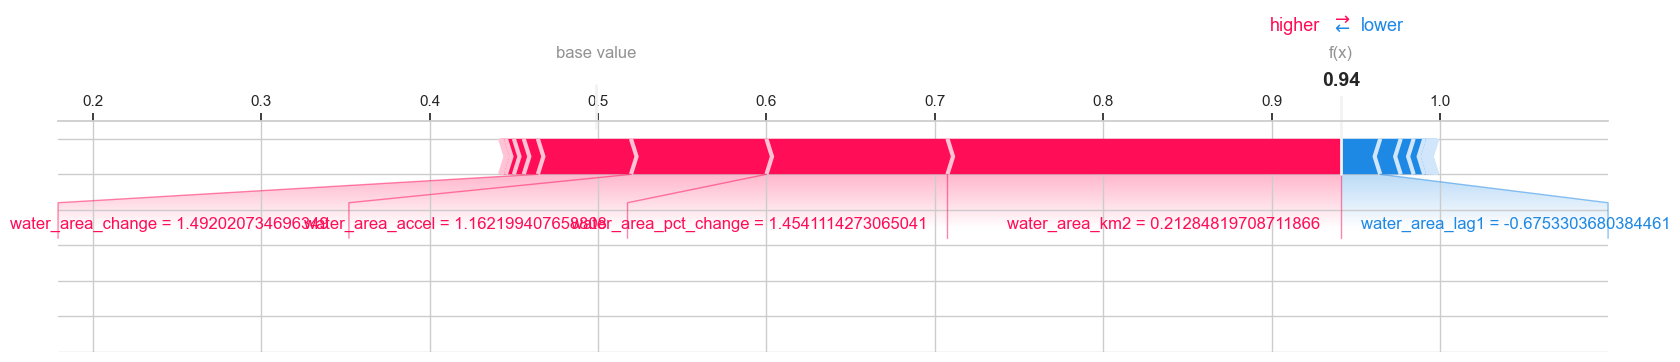

In [ ]:
# SHAP Force Plot for a single flood prediction (most likely flood case)
flood_idx = np.where(y_test.values == 1)[0][0]
shap.force_plot(
    ev,
    sv[flood_idx],
    pd.DataFrame(X_test_scaled, columns=FEATURE_COLS).iloc[flood_idx],
    matplotlib=True,
    show=True,
)

## 22. Risk Label Mapping

Map flood probability to 4 risk tiers (English + Urdu):

- **Low** (سبز): P < 25%
- **Medium** (پیلا): 25% ≤ P < 50%
- **High** (نارنجی): 50% ≤ P < 75%
- **Critical** (سرخ): P ≥ 75%


In [ ]:
def assign_risk(prob):
    """Map flood probability [0,1] to 4-tier risk label."""
    if prob < 0.25:
        return "Low (کم خطرہ)"
    elif prob < 0.50:
        return "Medium (درمیانہ خطرہ)"
    elif prob < 0.75:
        return "High (زیادہ خطرہ)"
    else:
        return "Critical (انتہائی خطرہ)"


# Apply to test set
test_results = X_test.copy()
test_results["flood_prob"] = (y_prob_best * 100).round(1)
test_results["flood_pred"] = y_pred_best
test_results["actual"] = y_test.values
test_results["risk_level"] = (
    y_prob_best.apply(lambda p: assign_risk(p))
    if hasattr(y_prob_best, "apply")
    else pd.Series(y_prob_best).apply(assign_risk).values
)

print("Risk label distribution:")
print(test_results["risk_level"].value_counts().to_string())

Risk label distribution:
risk_level
Low (کم خطرہ)              97
Critical (انتہائی خطرہ)    89
Medium (درمیانہ خطرہ)       4
High (زیادہ خطرہ)           1


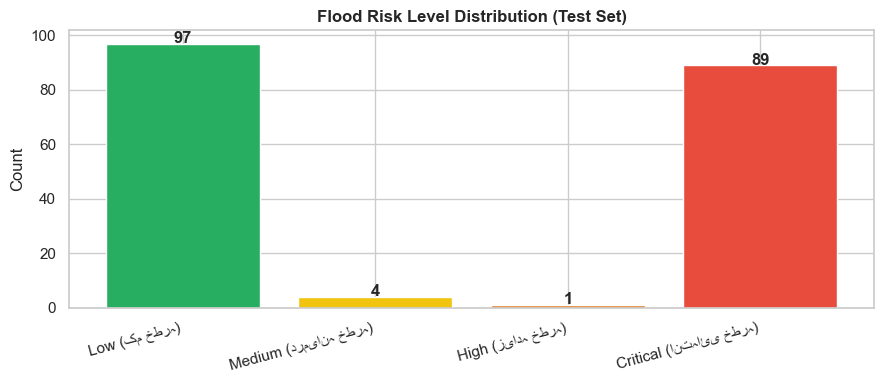


Sample predictions:


,flood_prob,risk_level,actual
21,29.9,Medium (درمیانہ خطرہ),0
359,20.0,Low (کم خطرہ),0
692,94.1,Critical (انتہائی خطرہ),1
309,11.6,Low (کم خطرہ),0
895,98.8,Critical (انتہائی خطرہ),1
509,0.8,Low (کم خطرہ),0
134,15.8,Low (کم خطرہ),0
343,0.0,Low (کم خطرہ),0
235,0.6,Low (کم خطرہ),0
574,93.4,Critical (انتہائی خطرہ),1


In [ ]:
# Risk level distribution plot
risk_order = [
    "Low (کم خطرہ)",
    "Medium (درمیانہ خطرہ)",
    "High (زیادہ خطرہ)",
    "Critical (انتہائی خطرہ)",
]
risk_colors = ["#27AE60", "#F1C40F", "#E67E22", "#E74C3C"]
risk_counts = (
    test_results["risk_level"].value_counts().reindex(risk_order, fill_value=0)
)

plt.figure(figsize=(9, 4))
bars = plt.bar(
    risk_counts.index, risk_counts.values, color=risk_colors, edgecolor="white"
)
for bar, cnt in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(cnt),
        ha="center",
        fontweight="bold",
    )
plt.title("Flood Risk Level Distribution (Test Set)", fontweight="bold")
plt.ylabel("Count")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("\nSample predictions:")
display(test_results[["flood_prob", "risk_level", "actual"]].head(10))

## 23. Save Model Artefacts


In [ ]:
# Save the best-performing model
joblib.dump(tuned_model, "best_model.pkl")
joblib.dump(FEATURE_COLS, "feature_cols.pkl")
# Transformers already saved: power_transformer.pkl, standard_scaler.pkl, district_encoder.pkl

if USE_KERAS:
    ann.save("ann_model.keras")
    print("Saved: ann_model.keras")

print("\nSaved artefacts:")
for f in [
    "best_model.pkl",
    "power_transformer.pkl",
    "standard_scaler.pkl",
    "district_encoder.pkl",
    "feature_cols.pkl",
]:
    exists = os.path.exists(f)
    size = os.path.getsize(f) // 1024 if exists else 0
    print(f'  {f:30s}  {size} KB  {"✅" if exists else "❌"}')


Saved artefacts:
  best_model.pkl                  891 KB  ✅
  power_transformer.pkl           0 KB  ✅
  standard_scaler.pkl             1 KB  ✅
  district_encoder.pkl            0 KB  ✅
  feature_cols.pkl                0 KB  ✅


In [ ]:
# ─── End-to-end prediction function (for Streamlit / submission) ───
def predict_flood_risk(input_df: pd.DataFrame) -> pd.DataFrame:
    """
    input_df: raw feature DataFrame (same schema as training data, with 'district' column)
    Returns: DataFrame with flood_probability (%) and risk_level columns.
    """
    _le = joblib.load("district_encoder.pkl")
    _pt = joblib.load("power_transformer.pkl")
    _sc = joblib.load("standard_scaler.pkl")
    _model = joblib.load("best_model.pkl")
    _fcols = joblib.load("feature_cols.pkl")

    df_in = input_df.copy()
    df_in["district_enc"] = _le.transform(df_in["district"].astype(str))

    X_in = df_in[_fcols].copy()
    X_in.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_in.fillna(X_in.median(), inplace=True)

    X_in_t = X_in.copy()
    if skewed_features:
        X_in_t[skewed_features] = _pt.transform(X_in[skewed_features])
    X_in_s = _sc.transform(X_in_t)

    probs = _model.predict_proba(X_in_s)[:, 1]
    result = pd.DataFrame(
        {
            "flood_probability_%": (probs * 100).round(1),
            "risk_level": [assign_risk(p) for p in probs],
        }
    )
    return result


print("predict_flood_risk() function ready for Streamlit integration.")
print("\n=== PIPELINE COMPLETE ===")

predict_flood_risk() function ready for Streamlit integration.

=== PIPELINE COMPLETE ===
